## Environment Setup

### Directories

In [13]:
import sys
from pathlib import Path
import importlib
import numpy as np

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [14]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
import skrom.problem_classes.masterclass as master
from skrom.rom.rom_error_est import *

problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")

### Plot Properties

In [3]:
# # Define a custom color palette with 19 distinct colors
from skrom.utils.visualization.color_palette import set_color_palette
from skrom.utils.visualization.generate_vtk import visualize2D 
set_color_palette();
import sci_mplstyle_package

In [15]:
generate_data = True
visualize = True
run_svd = True
run_rom = True
rom_report = True

## Full Order Simulation

In [16]:
# Offline stage
# Conditional execution block for simulation data generation
if generate_data:
    # Create an instance of the linear heat conduction simulation
    sim =  master.fom_simulation(num_snapshots=64)

    sim.run_simulation()


Snap 1/128 params=[ 0.10411342  0.59602831  0.69099882  2.92200888  2.          2.95181807
  0.         10.         30.        ]

Snap 2/128 params=[ 0.75147266  0.42344415  0.49562293  0.59156273  2.          3.48694407
  0.         10.         30.        ]
Snap 3/128 params=[ 0.99758711  0.96553221  0.92577458  3.25246121  2.          5.4269694
  0.         10.         30.        ]
Snap 4/128 params=[ 0.35033728  0.23763079  0.27732324  1.23378263  2.          0.34533461
  0.         10.         30.        ]
Snap 5/128 params=[ 0.46048662  0.85142344  0.36413387  1.71057869  2.          1.80647405
  0.         10.         30.        ]
Snap 6/128 params=[ 0.88371791  0.11641308  0.61925492  3.80688654  2.          3.84709178
  0.         10.         30.        ]
Snap 7/128 params=[ 0.63769998  0.7138259   0.13462825  0.09866275  2.          5.04920208
  0.         10.         30.        ]
Snap 8/128 params=[ 0.21457815  0.54844335  0.83579323  2.38369129  2.          1.46134313
  0. 

### Load Simulation Data

In [17]:
# Load data
# fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=Path().resolve() / "ROM_data")
# LS = np.asarray(fos_solutions)
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\Neutron_diffusion\problem_6b\ROM_data


### Generate training solution dataset

In [18]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = rom_data.param_list

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


128


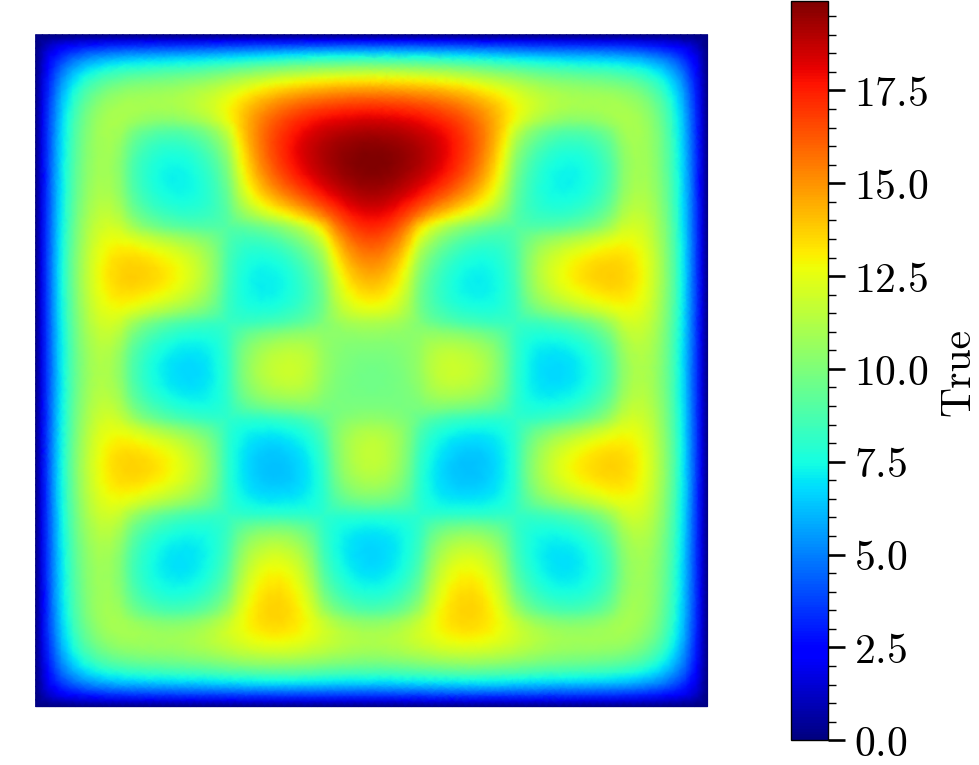

In [ ]:
if visualize:
    visualize2D(LS_test[11],rom_data.basis)

### Mean Subtraction

In [19]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Performing SVD on training snapshots

Number of modes selected: 64


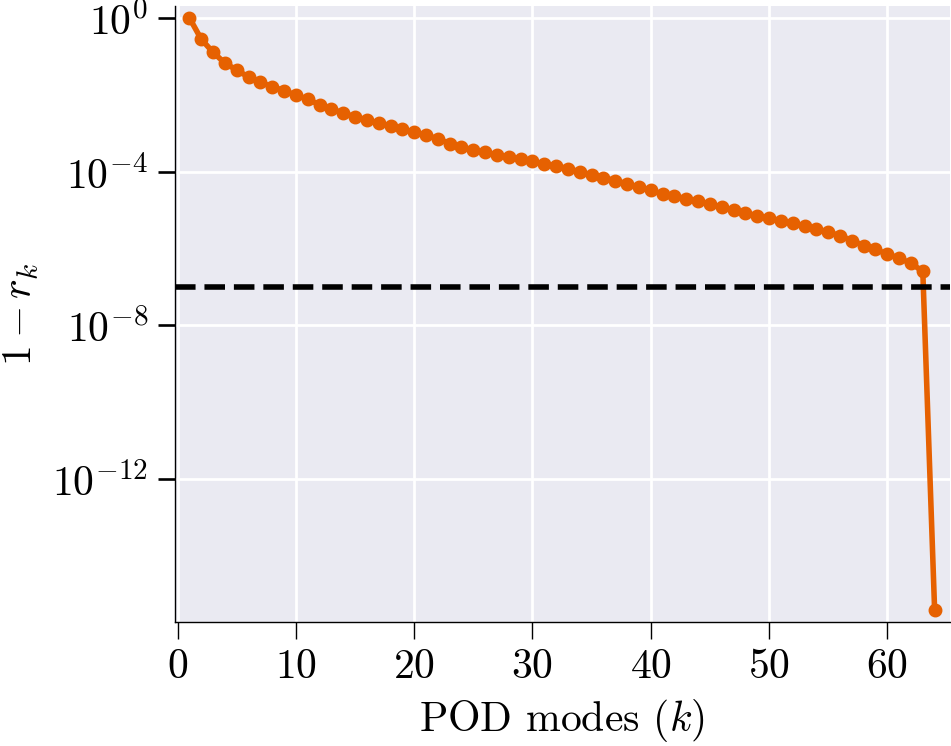

In [20]:
if run_svd:

    # Configure plot styling for POD analysis visualization
    plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
    plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

    # Perform Singular Value Decomposition (SVD) for POD mode selection
    # SVD decomposes the mean-centered training data to find optimal basis functions
    n_sel, U = svd_mode_selector(LS_train_ms,    # Input: mean-centered training snapshots
                                tolerance=1e-7,    # Convergence criterion for mode selection
                                modes=True)        # Return both number of modes and basis vectors


    # Extract the selected POD basis vectors (spatial modes)
    # V_sel contains the first n_sel most energetic POD modes
    # Shape: [N_dof, n_sel] - each column is a spatial basis function
    V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

    # Set axis labels for the POD energy plot (generated by svd_mode_selector)
    plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
    plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation

In [21]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    rom = master.rom_simulation(V_sel=V_sel,train_ref=LS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\Neutron_diffusion\problem_6b\ROM_data


In [22]:
if run_rom:
    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    rom.run_rom_simulation();

Snap 1/64 params=[ 0.87423022  0.88566492  0.5688314   1.57597682  2.          1.08208399
  0.         10.         30.        ]

Snap 2/64 params=[ 0.28487728  0.15896156  0.4033193   2.89372061  2.          3.12945136
  0.         10.         30.        ]
Snap 3/64 params=[ 0.46353482  0.74766845  0.89051302  0.22368962  2.          5.64112774
  0.         10.         30.        ]
Snap 4/64 params=[ 0.6054835   0.52021216  0.28203219  3.30850706  2.          2.13563992
  0.         10.         30.        ]
Snap 5/64 params=[ 0.67752771  0.64074615  0.49913851  3.58055148  2.          0.1008607
  0.         10.         30.        ]
Snap 6/64 params=[ 0.37039648  0.40389226  0.67156598  0.88731272  2.          4.1223795
  0.         10.         30.        ]
Snap 7/64 params=[ 0.20931729  0.99489777  0.17042609  2.24486613  2.          5.12903478
  0.         10.         30.        ]
Snap 8/64 params=[ 0.97088445  0.27297089  0.7998848   1.28549786  2.          2.65946633
  0.         10

In [23]:
if rom_report:
    #Assign values for the statistics
    LS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up[1:]
    ROM_relative_error = rom.rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 7.6026e-03
Relative L2 Error:        9.8324e-05
L∞ Error:                 2.2356e-02
Relative L∞ Error:        3.9575e-04
RMSE:                     9.9439e-04
MAE:                      3.3230e-04

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             0.0000e+00
95th Percentile Error:    1.6385e-03

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 6.0223e-07
Max Rel L2 Error over time/parameter: 2.7197e-06
Min Rel L2 Error over time/parameter: 1.3373e-07
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

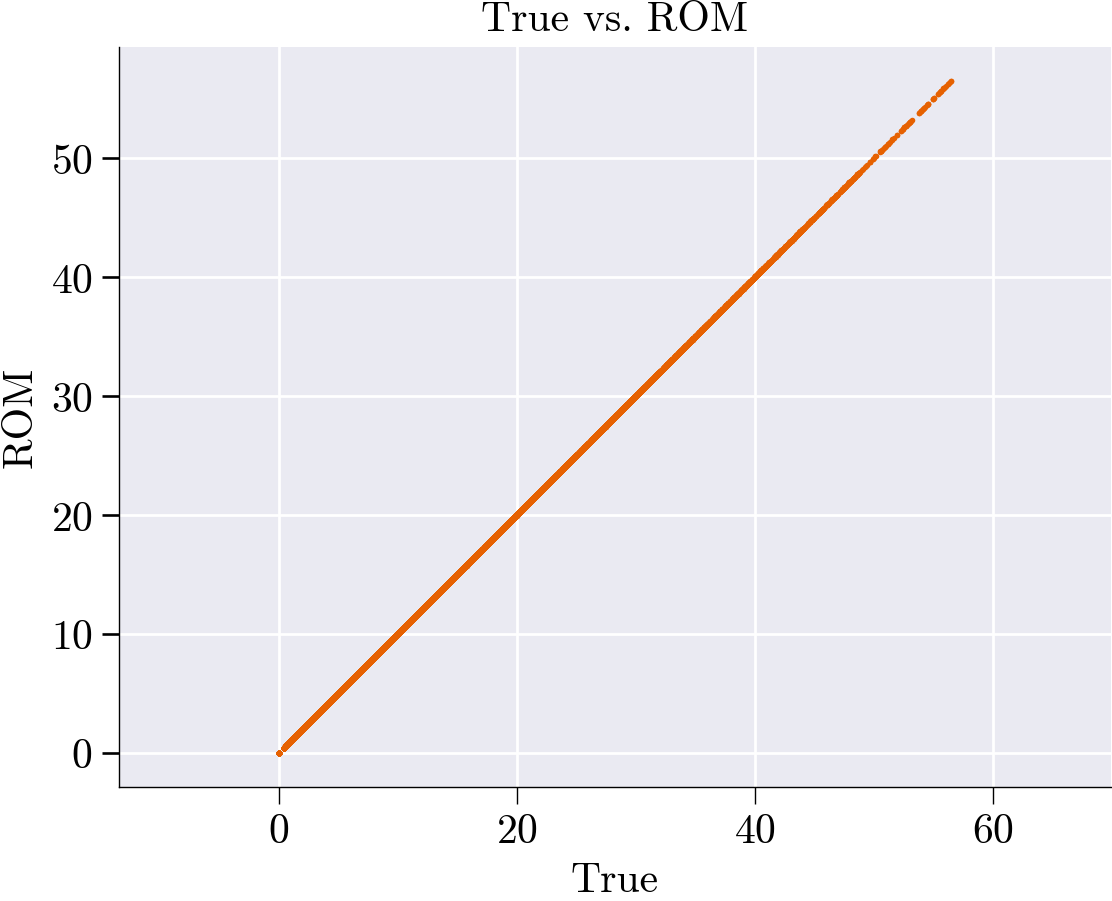

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


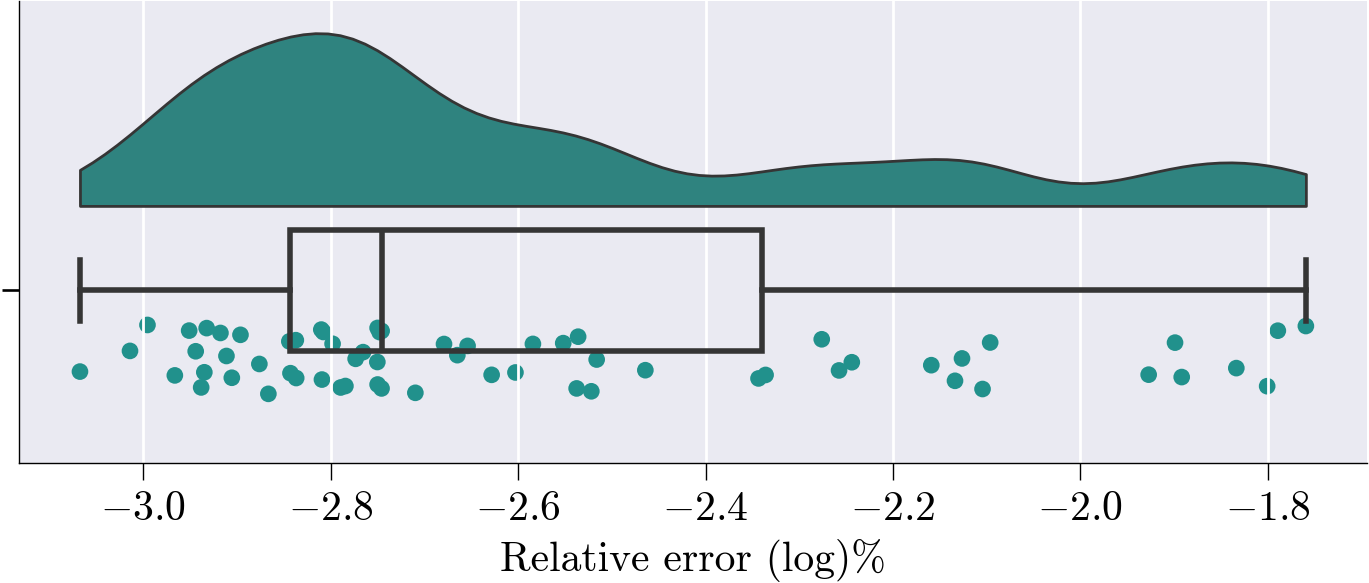

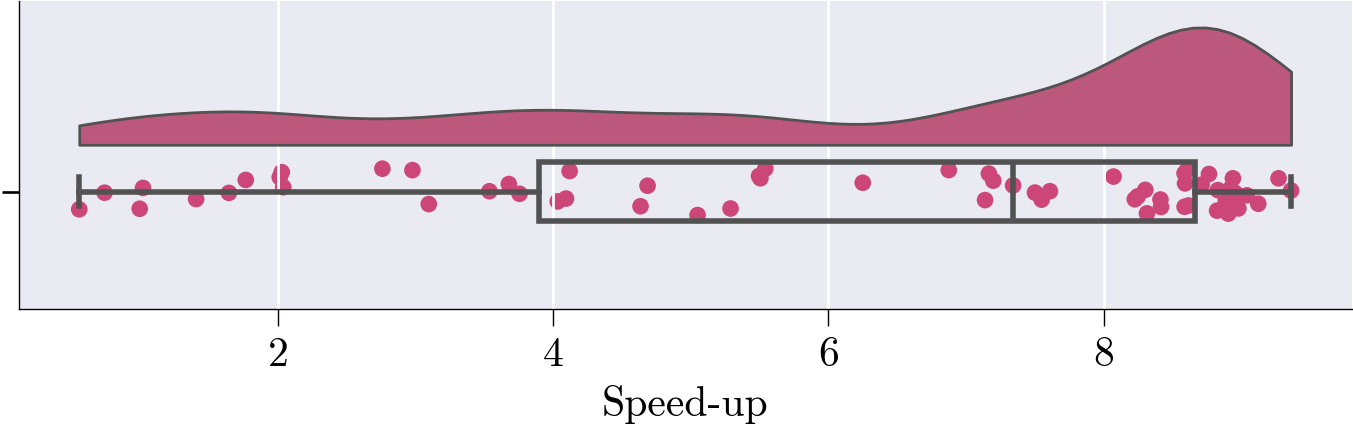

In [24]:
# --- ROM error analysis ---
if rom_report:
    
    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        LS_test[1:],                   # full-order (true) solution snapshots
        LS_rom[1:],              # hyper-ROM-generated solution snapshots
        rom.rom_error[1:],   # precomputed relative error of the hyper-ROM
        rom.speed_up[1:],         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )
